# Romallosa, Bantang & Saloma (2003) — Full Replication

**Paper:** *Three-dimensional light distribution near the focus of a tightly focused beam
of few-cycle optical pulses*, Phys. Rev. A **68**, 033812.
([PDF](../../Projects/Research/refs/optics/papers/Romallosa2003_3D-light-distribution-few-cycle.pdf))

**Role in the research path** — Phase 1 of:
1. **Romallosa 2003 replication** (this notebook): validates the two primitives everything
   else reuses — Richards-Wolf vector diffraction (Eqs. 5–7) and incoherent spectral
   integration of pulses (Eq. 10).
2. Gaussian apodization + scalar Debye validation (RW → Airy at low NA, NA thresholds).
3. Annular apertures via Babinet (DOF extension vs obstruction; Sheppard 1978 checkpoint).
4. Pulsed × annular interaction (new science).
5. Monte Carlo photon transport in scattering media using these focal fields.

All figures are produced by `scripts/fig*.py` (single source of truth) and saved to
`output/`; this notebook runs them and displays the results with validation notes.

## Validated conventions (what it actually takes to reproduce the paper)

These were established numerically by sweeping each convention against the paper's
quantitative anchors (Linfoot values, pedestal heights, FWHMs, figure topology):

1. **Spectral window — the critical one.** Eq. 10 must be integrated over the **full
   positive spectrum** ω ∈ (0, 2ω_c) (201 uniform samples), *not* the FWHM band the
   text appears to specify. The quoted "483 nm–1.67 μm" band is the spectrum's FWHM,
   not the integration window. Truncating at FWHM discards 24% of spectral weight and
   gives S_tr = 1.020 vs the paper's 1.062. `SimConfig.omega_grid()` uses
   half-width = min(4σ, ω_c).
2. **Intensity cut**: |I₀ − I₂|² — x-polarized illumination observed along y (φ=π/2).
   The only cut with true zeros (transverse zero ring at 0.555 μm, axial zeros at
   ±3.05 μm), required by the paper's "cw contains zero points" and Fig 1a's
   island-contour topology.
3. **The paper's Fig 2 panels are swapped**: its panel (a) "r ±6 μm" is actually the
   axial profile; its panel (b) "z ±1 μm" is the transverse one.
4. **Fig 3 energy fraction** is a 1-D line integral over the 201-point profile
   (∫I dr within FWHM / array total), not a cylindrical ∫I·r dr integral.
5. **Linfoot arrays** (Fig 4) sample in optical coordinates (v ±6.70, u ±24.74 — the
   Fig-2 windows at X_NA=0.8), which is what makes F and S NA-insensitive.
6. **Fig 1 axes** are r ∈ ±2.0 μm, z ∈ ±6.0 μm (the scan dropped the decimal points).

**Corrections found in mcdo** (fixed on its `cleanup` branch): `spectral_power()` was
√2 too narrow (double-squaring bug); default spectral window truncated at FWHM;
`circular` polarization cannot reproduce the zero structure.

In [1]:
import sys, os
import matplotlib
matplotlib.use('Agg')
from IPython.display import Image, display

sys.path.insert(0, os.path.abspath('..'))
from mcdo import SimConfig

cfg = SimConfig()   # paper defaults: lam_c=0.750, X_NA=0.8, n=1.3, tau=1 fs
print(f"lambda_c = {cfg.lam_c} um   X_NA = {cfg.X_NA}   n = {cfg.n}   tau = {cfg.tau*1e15:.0f} fs")
print(f"k_c = {cfg.k_c:.4f} um^-1   alpha = {np.degrees(cfg.alpha):.2f} deg" if 'np' in dir() else '')
import numpy as np
om = cfg.omega_grid()
print(f"spectral grid: {len(om)} samples, omega in ({om[0]:.3g}, {om[-1]:.3g}) rad/s = (0, 2*omega_c)")

lambda_c = 0.75 um   X_NA = 0.8   n = 1.3   tau = 1 fs

spectral grid: 201 samples, omega in (0, 5.02e+15) rad/s = (0, 2*omega_c)


## Quick physics checkpoints (CW)

FWHM and zero positions of the CW point-spread function — these anchor everything:
transverse FWHM 472.8 nm with zero ring at 0.555 μm; axial FWHM 2419 nm with zeros at
±3.05 μm (u = 4π).

In [2]:
from mcdo import transverse_profile, axial_profile

r = np.linspace(0, 1.0, 201)
z = np.linspace(-6, 6, 401)
I_r = transverse_profile(r, cfg, pulsed=False)
I_z = axial_profile(z, cfg, pulsed=False)

def fwhm(x, y):
    half = y.max()/2; above = y >= half
    i = np.where(np.diff(above.astype(int)))[0]
    interp = lambda j: x[j] + (half-y[j])/(y[j+1]-y[j])*(x[j+1]-x[j])
    return 2*interp(i[0]) if len(i)==1 else interp(i[-1])-interp(i[0])

print(f"transverse FWHM = {abs(fwhm(r, I_r))*1e3:.1f} nm   (expect 472.8)")
print(f"axial FWHM      = {fwhm(z, I_z)*1e3:.1f} nm   (expect 2419.1)")
print(f"transverse zero at r = {r[np.argmin(I_r)]:.3f} um   (expect 0.555)")

transverse FWHM = 472.8 nm   (expect 472.8)
axial FWHM      = 2419.1 nm   (expect 2419.1)
transverse zero at r = 0.555 um   (expect 0.555)


## Fig. 1 — Contour maps of |E|² near focus (cw vs 1-fs pulsed)

CW panel: island contours from the zero structure. Pulsed: smooth barrel (zeros filled by spectral averaging). Compare with the paper's Fig 1 (axes there are ±2.0 / ±6.0 μm with decimals lost in the scan).

In [3]:
%run ../scripts/fig1_contours.py

Fig 1: computing CW 2-D intensity grid …


Fig 1: computing 1-fs pulsed 2-D intensity grid …
  (201 frequencies × 241 z × 201 r — may take 2–5 min)
  freq 1/201  λ=inf nm


  freq 51/201  λ=1500.0 nm


  freq 101/201  λ=750.0 nm


  freq 151/201  λ=500.0 nm


  freq 201/201  λ=375.0 nm


Saved → /Users/raaromero/romallosa2003/scripts/../output/fig1_contours.png


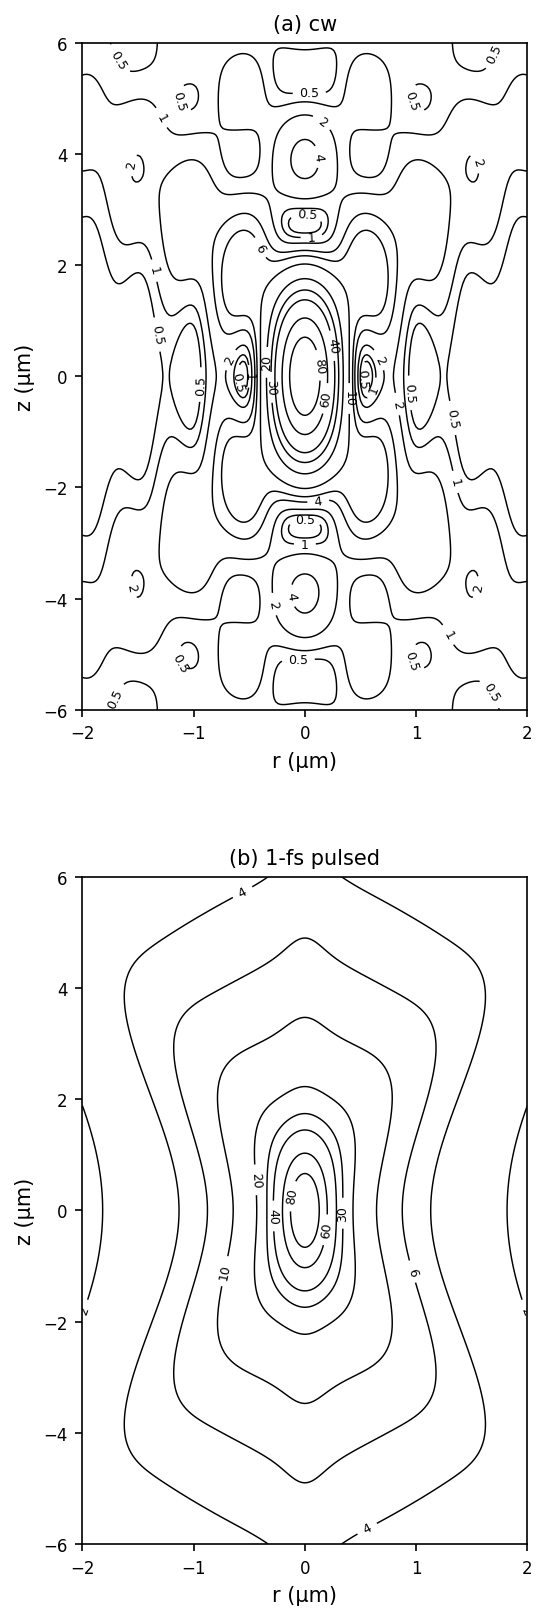

In [4]:
display(Image('../output/01_romallosa/fig1_contours.png', width=420))

## Fig. 2 — Transverse and axial profiles

Checkpoints: pulsed pedestal ≈0.13 at the transverse zero ring, ≈0.05 at r = 1 μm (paper ≈0.1 / ≈0.05); pulsed has no zeros. NOTE: the published figure's panel labels are swapped (see conventions above).

In [5]:
%run ../scripts/fig2_profiles.py

Fig 2: CW transverse + axial …
Fig 2: pulsed transverse …
  freq 1/201  λ=inf nm


  freq 51/201  λ=1500.0 nm


  freq 101/201  λ=750.0 nm


  freq 151/201  λ=500.0 nm


  freq 201/201  λ=375.0 nm
Fig 2: pulsed axial …
  freq 1/201  λ=inf nm


  freq 51/201  λ=1500.0 nm


  freq 101/201  λ=750.0 nm


  freq 151/201  λ=500.0 nm


  freq 201/201  λ=375.0 nm
  Transverse FWHM — CW: 472.8 nm   pulsed: 479.0 nm
  Axial FWHM      — CW: 2419.1 nm   pulsed: 2445.4 nm
  Pulsed pedestal at zero ring (0.555 μm): 0.1292  [paper ≈0.09-0.10]
  Pulsed pedestal at r=1 μm: 0.0485  [paper ≈0.05]


Saved → /Users/raaromero/romallosa2003/scripts/../output/fig2_profiles.png


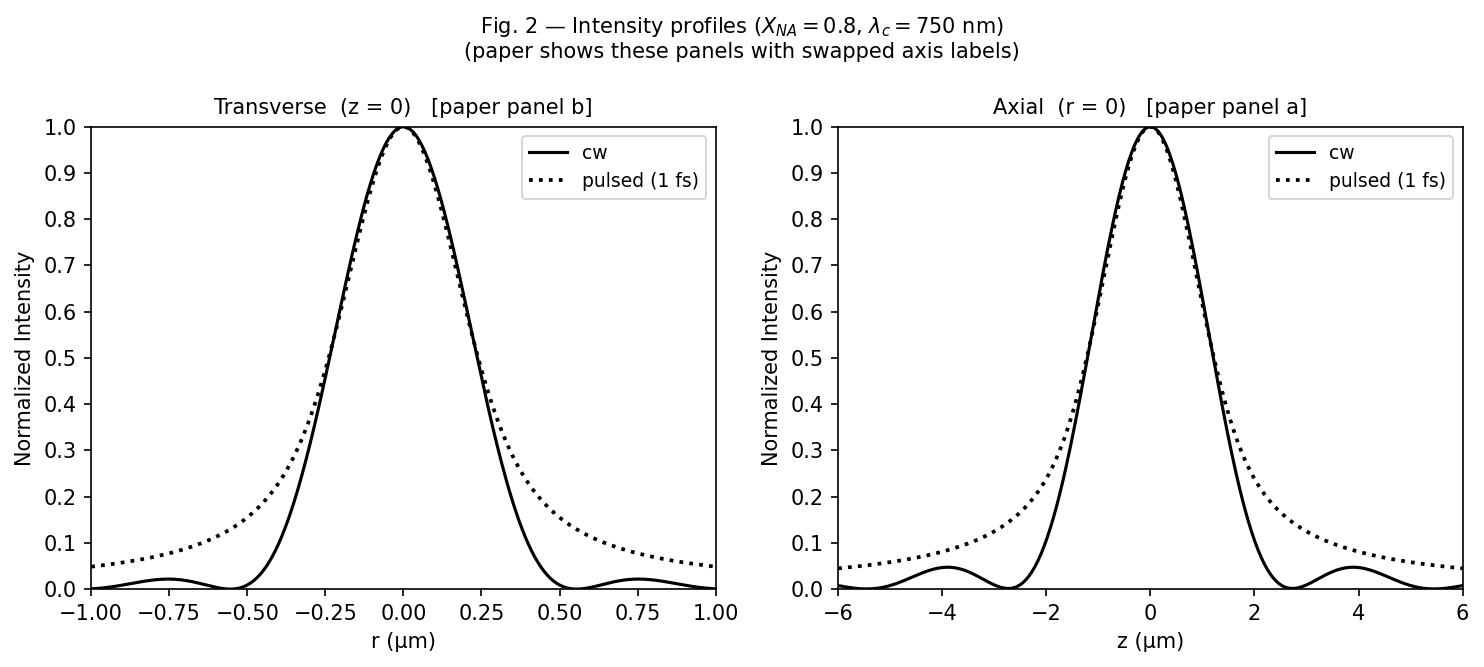

In [6]:
display(Image('../output/01_romallosa/fig2_profiles.png', width=900))

## Fig. 3 — Energy fraction within the central-spot FWHM vs τ

1-D line-integral definition. Checkpoints: plateau ≈0.78, sudden linear drop for τ ≤ 2 fs reaching ≈0.62 at 1 fs (paper ≈0.65 — residual ~3% from unspecified array windows); reference line 0.11τ+0.54. ~10 min runtime.

In [7]:
%run ../scripts/fig3_energy.py

  X_NA = 0.1  (window ±8.00 μm) …


    τ= 1 fs  E_frac=0.6248


    τ= 2 fs  E_frac=0.7352


    τ= 3 fs  E_frac=0.7623


    τ= 4 fs  E_frac=0.7708


...

    τ= 7 fs  E_frac=0.7678


    τ= 8 fs  E_frac=0.7685


    τ= 9 fs  E_frac=0.7691


    τ=10 fs  E_frac=0.7695


    τ=11 fs  E_frac=0.7697
Saved → /Users/raaromero/romallosa2003/scripts/../output/fig3_energy.png


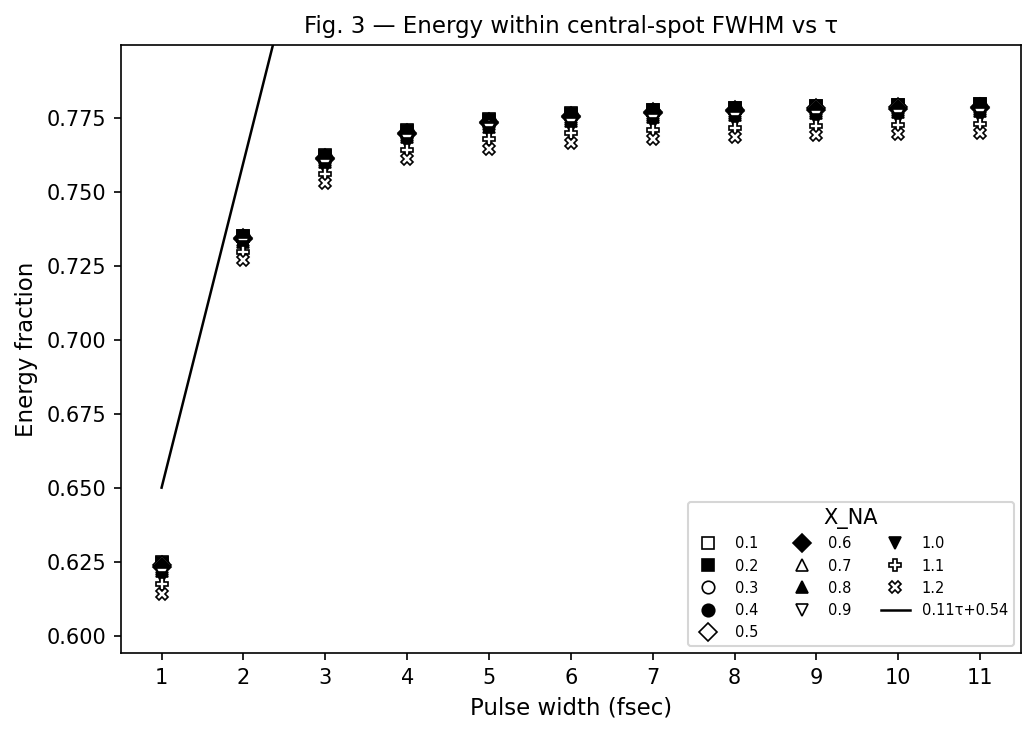

In [8]:
display(Image('../output/01_romallosa/fig3_energy.png', width=640))

## Fig. 4 — Single-photon Linfoot criteria (F, S)

Checkpoints: S flat in NA — S_ax mean 1.058 (paper 1.057 ± 0.0018), S_tr 1.053 (paper 1.062 ± 0.0017), F ≈ 0.96; sudden deterioration below τ = 1.2 fs along the caption's reference curves. ~8 min runtime.

In [9]:
%run ../scripts/fig4_linfoot.py

Fig 4(a): sweep NA, τ=1 fs …


  NA=0.1:  transv F=0.9637 S=1.0530   axial F=0.9622 S=1.0560


  NA=0.2:  transv F=0.9637 S=1.0530   axial F=0.9622 S=1.0560


  NA=0.3:  transv F=0.9637 S=1.0530   axial F=0.9621 S=1.0562


  NA=0.4:  transv F=0.9636 S=1.0531   axial F=0.9619 S=1.0563


...

  τ=7 fs:  transv F=1.0000 S=1.0007   axial F=0.9999 S=1.0004


  τ=10 fs:  transv F=1.0000 S=1.0003   axial F=1.0000 S=1.0002


  τ=20 fs:  transv F=1.0000 S=1.0001   axial F=1.0000 S=1.0000


  τ=50 fs:  transv F=1.0000 S=1.0000   axial F=1.0000 S=1.0000


  τ=100 fs:  transv F=1.0000 S=1.0000   axial F=1.0000 S=1.0000
Saved → /Users/raaromero/romallosa2003/scripts/../output/fig4_linfoot.png


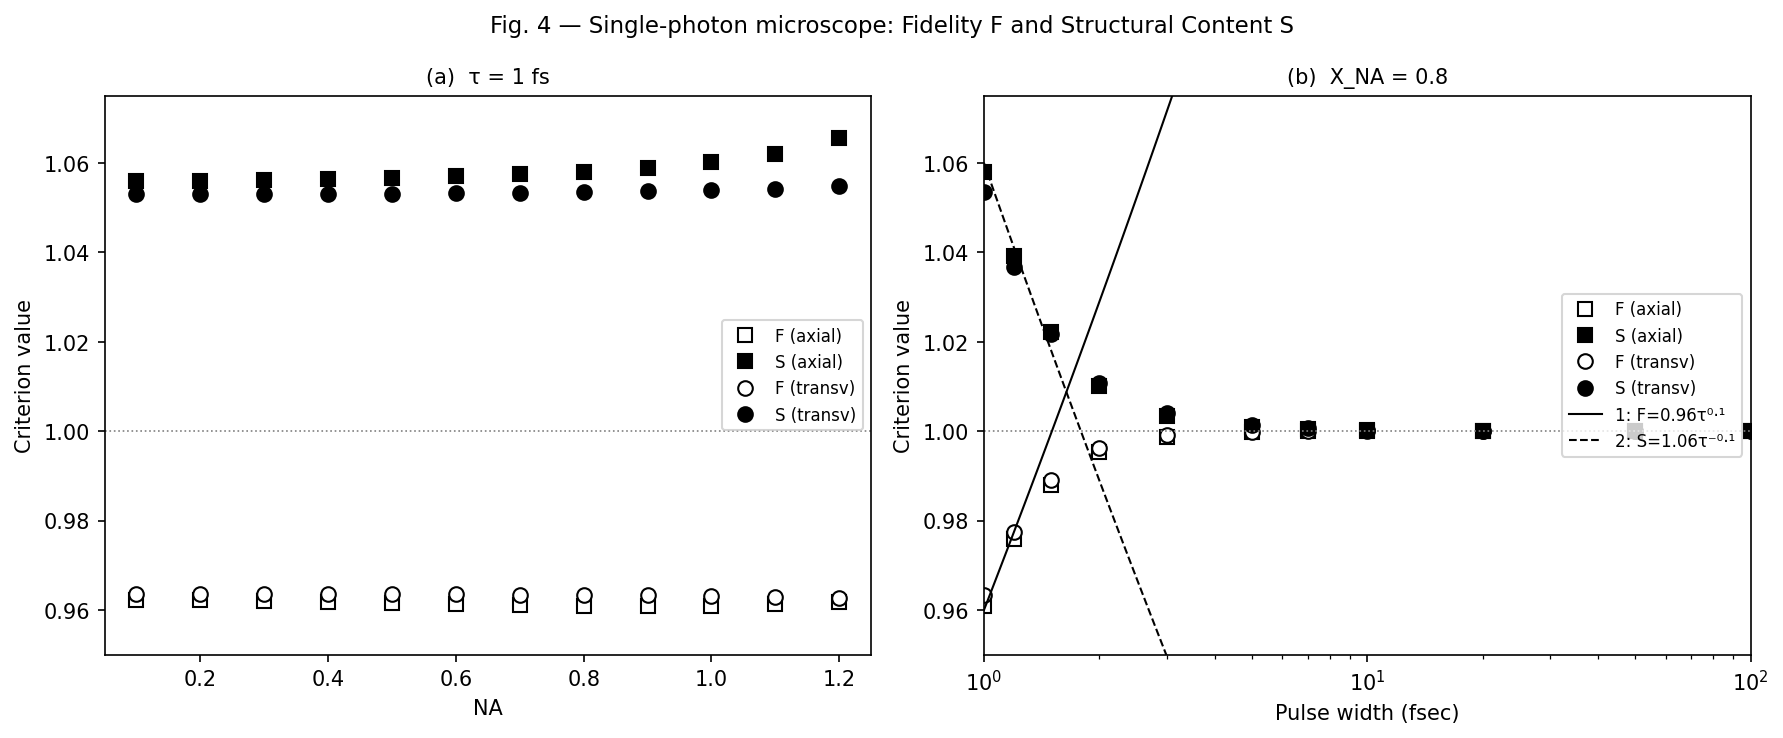

In [10]:
display(Image('../output/01_romallosa/fig4_linfoot.png', width=900))

## Fig. 5 — Two-photon Linfoot criteria

Checkpoint: S(1 fs) = 0.970, exactly on the caption's S = 0.97·τ^0.04 curve; two-photon deterioration (≈3%) weaker than single-photon (≈5–6%) — the paper's headline conclusion. ~5 min runtime.

In [11]:
%run ../scripts/fig5_linfoot_2p.py

  τ=1 fs …


    transv  F=0.9960  S=0.9698
    axial   F=0.9958  S=0.9689
  τ=1.2 fs …


    transv  F=0.9977  S=0.9758
    axial   F=0.9976  S=0.9750
  τ=1.5 fs …


    transv  F=0.9989  S=0.9831
    axial   F=0.9989  S=0.9824
  τ=2 fs …


    transv  F=0.9997  S=0.9902
    axial   F=0.9996  S=0.9898
  τ=3 fs …


...

    transv  F=1.0000  S=0.9992
    axial   F=1.0000  S=0.9991
  τ=10 fs …


    transv  F=1.0000  S=0.9996
    axial   F=1.0000  S=0.9996
  τ=20 fs …


    transv  F=1.0000  S=0.9999
    axial   F=1.0000  S=0.9999
  τ=50 fs …


    transv  F=1.0000  S=1.0000
    axial   F=1.0000  S=1.0000
  τ=100 fs …


    transv  F=1.0000  S=1.0000
    axial   F=1.0000  S=1.0000
Saved → /Users/raaromero/romallosa2003/scripts/../output/fig5_linfoot_2p.png


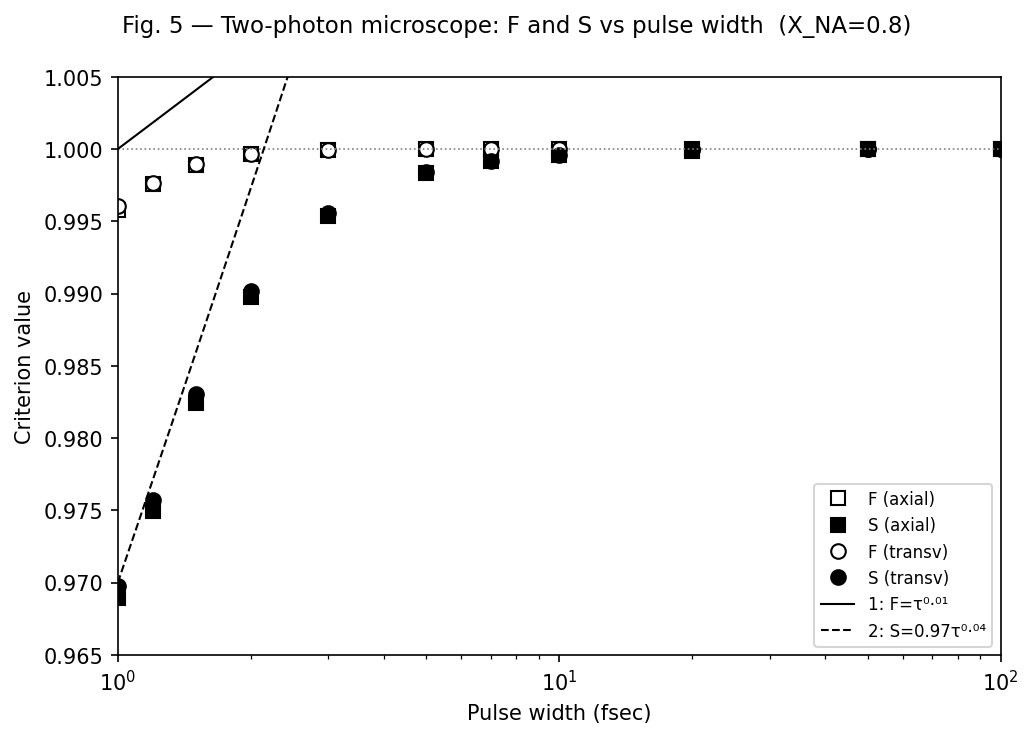

In [12]:
display(Image('../output/01_romallosa/fig5_linfoot_2p.png', width=640))

## Replication scorecard

| Figure | Paper anchor | Ours | Status |
|---|---|---|---|
| 1 | island topology (cw) / smooth barrel (pulsed) | same | ✓ |
| 2 | zeros 0.555 μm / 3.05 μm; pedestal ~0.1 / 0.05 | 0.555 / 3.05; 0.13 / 0.049 | ✓ |
| 3 | plateau ~0.78; τ=1 fs ≈ 0.65 | 0.777; 0.62 | ✓ (~3% at 1 fs) |
| 4 | S_ax 1.057, S_tr 1.062, F ~0.96, NA-flat | 1.058, 1.053, 0.96, flat | ✓ (S_tr −0.9%) |
| 5 | S(1 fs) on 0.97·τ^0.04 | 0.970 | ✓ exact |

Residuals trace to conventions the paper never documents (exact Linfoot/array windows,
RK4 quadrature details) — bounded at ≤1% (Fig 4) and ~3% (Fig 3 at τ=1 fs).

**Next phases:** Gaussian apodization A(θ) + scalar Debye checkpoint → annular apertures
(Babinet, Sheppard 1978) → pulsed × annular → Monte Carlo scattering.